## Problem Statement

Analyze men’s and women’s perfume e-commerce data to evaluate **sales performance, brand and product demand, pricing patterns, and inventory availability**. The project aims to identify high-performing and underperforming products, detect potential stock-out and inventory risks, compare men’s and women’s segments, and provide actionable insights to support **restocking, promotion, pricing, and product strategy decisions**.


In [117]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
# Reading the dataset into goggle colab
df1=pd.read_csv(r'ebay_mens_perfume.csv')

# Performing basic checks

In [119]:
# Returns the number of rows and columns
df1.shape


(1000, 10)

In [120]:
# Returns the first 5 rows from dataset
df1.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


In [121]:
# Returns the last five rows from dataset
df1.tail()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"
999,Estee Lauder,Beyond Paradise by Estee Lauder for Men Cologn...,Cologne spray,17.49,US $17.49/ea,10.0,More than 10 available / 24 sold,24.0,"Feb 28, 2024 07:27:01 PST","Keyport, New Jersey, United States"


In [122]:
# Returns the details like column name , non-null count , datatype,memory usage
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [123]:
# Returns the statistical report for numerical column
df1.describe()

,price,available,sold
count,1000.000000,889.000000,994.000000
mean,46.481200,20.046119,766.266600
std,35.527862,61.547985,3200.971733
min,3.000000,2.000000,1.000000
25%,22.990000,5.000000,14.000000
50%,35.710000,10.000000,49.500000
75%,59.000000,10.000000,320.500000
max,259.090000,842.000000,54052.000000


In [124]:
# viewing the datatype of integer and float type columns
df1.select_dtypes(include=['int64','float64'])

,price,available,sold
0,84.99,10.0,116.0
1,109.99,8.0,48.0
2,100.00,10.0,27.0
3,44.99,2.0,159.0
4,16.91,NaN,156.0
...,...,...,...
995,20.28,45.0,1613.0
996,30.58,10.0,31.0
997,39.99,2.0,305.0
998,9.99,2.0,22.0


In [125]:
# viewing the datatype of categorial columns
df1.select_dtypes(include='object')

,brand,title,type,priceWithCurrency,availableText,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,US $84.99/ea,More than 10 available / 116 sold,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,US $109.99,8 available / 48 sold,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,US $100.00,More than 10 available / 27 sold,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,US $44.99/ea,2 available / 159 sold,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,US $16.91,Limited quantity available / 156 sold,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,US $20.28/ea,"45 available / 1,613 sold","May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,US $30.58,More than 10 available / 31 sold,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,US $39.99/ea,2 available / 305 sold,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,US $9.99/ea,2 available / 22 sold,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"


In [126]:
df1['sold'].isnull().sum()

np.int64(6)

In [127]:
df1.drop_duplicates()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"


In [128]:
df1['sold'].isnull().sum()

np.int64(6)

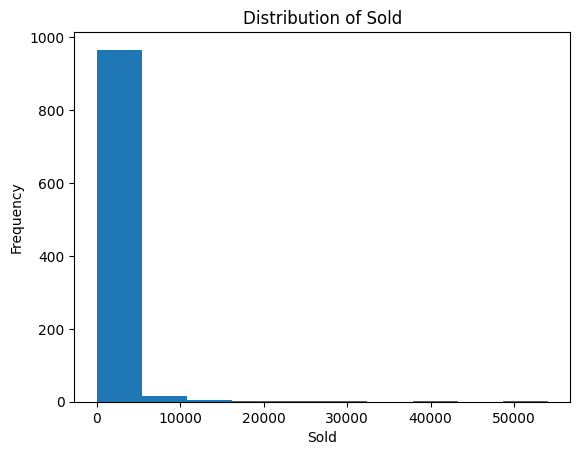

In [129]:
plt.hist(df1['sold'])
plt.xlabel('Sold')
plt.ylabel('Frequency')
plt.title('Distribution of Sold')
plt.show()

In [130]:
df1['sold']=df1['sold'].fillna(df1['sold'].median())

In [131]:
df1['sold'].isnull().sum()

np.int64(0)

In [132]:
df1.isnull().sum()

,0
brand,1
title,0
type,3
price,0
priceWithCurrency,0
available,111
availableText,3
sold,0
lastUpdated,53
itemLocation,0


In [133]:
df1['brand'].mode()[0]

'Giorgio Armani'

In [134]:
df1['brand']=df1['brand'].fillna('Giorgio Armani')

In [135]:
df1['type'].mode()[0]

'Eau de Toilette'

In [136]:
df1.isnull().sum()

,0
brand,0
title,0
type,3
price,0
priceWithCurrency,0
available,111
availableText,3
sold,0
lastUpdated,53
itemLocation,0


In [137]:
df1['type']=df1['type'].fillna(df1['type'].mode()[0])

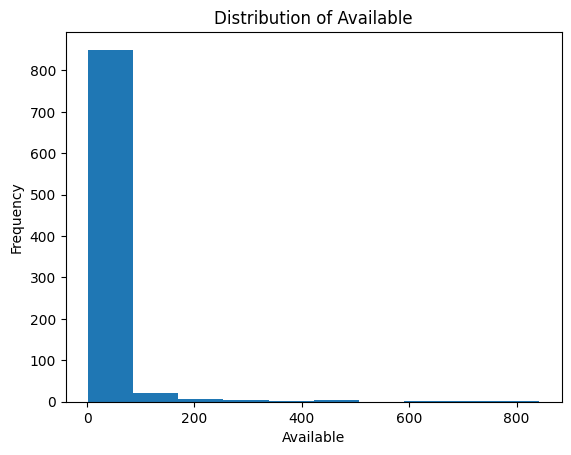

In [138]:
plt.hist(df1['available'])
plt.xlabel('Available')
plt.ylabel('Frequency')
plt.title('Distribution of Available')
plt.show()

In [139]:
df1['available']=df1['available'].fillna(df1['available'].median())

In [140]:
df1['available'].isnull().sum()

np.int64(0)

In [141]:
df1

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,10.0,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"


In [142]:
df1['available'] = pd.to_numeric(df1['available'], errors='coerce')

In [143]:
df1['available'] = df1['available'].astype(int)

In [144]:
df1['sold'] = df1['sold'].astype(int)

In [145]:
df1['sold']

,sold
0,116
1,48
2,27
3,159
4,156
...,...
995,1613
996,31
997,305
998,22


In [146]:
df1.isnull().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,0
availableText,3
sold,0
lastUpdated,53
itemLocation,0


In [147]:
df1['lastUpdated'] = pd.to_datetime(df1['lastUpdated'], errors='coerce', utc=True)


/tmp/ipykernel_1696/2555775414.py:1: FutureWarning: Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df1['lastUpdated'] = pd.to_datetime(df1['lastUpdated'], errors='coerce', utc=True)


In [148]:
df1['lastUpdated']

,lastUpdated
0,2024-05-24 10:03:04+00:00
1,2024-05-23 23:07:49+00:00
2,2024-05-22 21:55:43+00:00
3,2024-05-24 03:30:43+00:00
4,2024-05-24 07:56:25+00:00
...,...
995,2024-05-24 08:14:07+00:00
996,2024-05-23 08:39:30+00:00
997,2024-05-23 15:27:18+00:00
998,2024-05-20 13:20:54+00:00


# Checking the missing values

In [149]:
df1.isnull().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,0
availableText,3
sold,0
lastUpdated,122
itemLocation,0


In [150]:
df1 = df1.dropna(subset=['lastUpdated'])

In [151]:
df1.shape

(878, 10)

In [152]:
df1.isnull().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,0
availableText,0
sold,0
lastUpdated,0
itemLocation,0


# Checking the datatypes


In [153]:
df1.dtypes

,0
brand,object
title,object
type,object
price,float64
priceWithCurrency,object
available,int64
availableText,object
sold,int64
lastUpdated,"datetime64[ns, UTC]"
itemLocation,object


# Identifying the outliers

In [154]:
df1.select_dtypes(include=['int64'])


,available,sold
0,10,116
1,8,48
2,10,27
3,2,159
4,10,156
...,...,...
993,10,177
995,45,1613
996,10,31
997,2,305


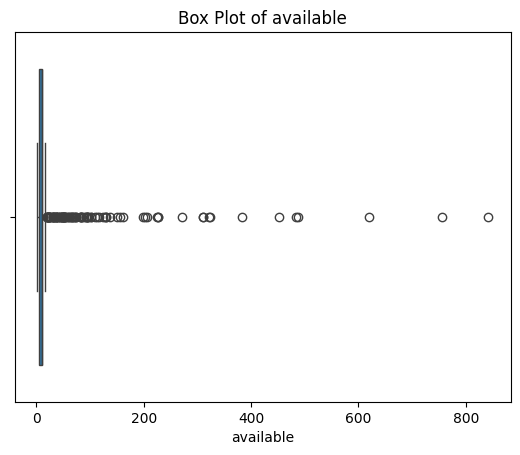

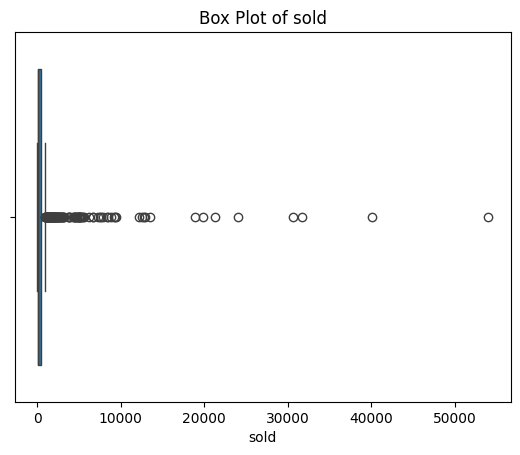

In [155]:
num_cols = ['available', 'sold']

for col in num_cols:
    sns.boxplot(x=df1[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

Outliers are present in available and sold column

# Dropped availableText column since it was unnecessary

In [156]:
df1.drop(columns=['availableText'], inplace=True)

/tmp/ipykernel_1696/4142631971.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(columns=['availableText'], inplace=True)


# Detecting outliers by checking the distribution of sold and available columns


#Since the distribution is skewed we will go with IQR method

In [157]:
# find outliers in sold
Q1 = df1.loc[:,'sold'].quantile(0.25)
Q3 = df1.loc[:,'sold'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5* IQR


In [158]:
# filter values less than lower limit
df1[df1.loc[:,'sold']<lower_limit]

,brand,title,type,price,priceWithCurrency,available,sold,lastUpdated,itemLocation


In [159]:
# filter values greater than upper limit
df1[df1.loc[:,'sold']>upper_limit]

,brand,title,type,price,priceWithCurrency,available,sold,lastUpdated,itemLocation
20,Dolce & Gabbana,Light Blue by Dolce & Gabbana 4.2 oz Cologne f...,Eau de Toilette,29.94,US $29.94/ea,10,9208,2024-05-23 20:04:11+00:00,"Hackensack, New Jersey, United States"
32,Armaf,ARMAF CLUB DE NUIT INTENSE 3.6 oz FOR MEN EDT ...,Eau de Toilette,32.85,US $32.85/ea,10,8385,2024-05-17 15:41:45+00:00,"Houston, Texas, United States"
34,Guy Laroche,DRAKKAR NOIR by Guy Laroche 3.4 oz / 3.3 oz ed...,Eau de Toilette,16.98,US $16.98/ea,620,2345,2024-05-23 18:45:23+00:00,"Dallas, Texas, United States"
35,Montblanc,MONT BLANC LEGEND 3.3 / 3.4 oz EDT Cologne for...,Eau de Toilette,32.89,US $32.89/ea,383,5032,2024-05-21 07:59:07+00:00,"Dallas, Texas, United States"
39,Calvin Klein,Eternity for Men by Calvin Klein cologne EDT 6...,Eau de Toilette,40.60,US $40.60/ea,10,5582,2024-05-24 09:35:06+00:00,"Dallas, Texas, United States"
...,...,...,...,...,...,...,...,...,...
944,Carolina Herrera,HERRERA FOR MEN * Carolina Herrera Cologne * E...,Eau de Toilette,66.52,US $66.52/ea,10,1963,2024-05-15 10:37:08+00:00,"Hackensack, New Jersey, United States"
947,Dvyne Fragrances,Assorted Body Oils - 100% Pure Uncut Fragrance...,Body Oil,8.00,US $8.00/ea,10,1113,2024-05-22 08:22:07+00:00,"Fort Lauderdale, Florida, United States"
954,Perry Ellis,360 Red by Perry Ellis 6.7 / 6.8 oz EDT Cologn...,Eau de Toilette,40.13,US $40.13,9,2703,2024-05-22 15:05:34+00:00,"Hackensack, New Jersey, United States"
988,Michael Jordan,Michael Jordan by Michael Jordan 3.4 oz Cologn...,Eau de Cologne,20.48,US $20.48/ea,10,2624,2024-05-22 21:41:09+00:00,"Hackensack, New Jersey, United States"


In [160]:
# find %
len(df1[(df1.loc[:,'sold']<lower_limit)|(df1.loc[:,'sold']>upper_limit)])/len(df1)*100

14.123006833712983

In [161]:
df1['priceWithCurrency'] = (
    df1['priceWithCurrency']
    .str.replace('US $', '', regex=False)
    .str.replace('/ea', '', regex=False)
    .str.strip()
)

df1['priceWithCurrency'] = pd.to_numeric(df1['priceWithCurrency'], errors='coerce')

/tmp/ipykernel_1696/3714338224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['priceWithCurrency'] = (
/tmp/ipykernel_1696/3714338224.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['priceWithCurrency'] = pd.to_numeric(df1['priceWithCurrency'], errors='coerce')


In [162]:
df1['priceWithCurrency']

,priceWithCurrency
0,84.99
1,109.99
2,100.00
3,44.99
4,16.91
...,...
993,24.25
995,20.28
996,30.58
997,39.99


In [163]:
# Convert all text columns to Proper Case
text_columns = df1.select_dtypes(include='object').columns

for col in text_columns:
    df1[col] = df1[col].str.strip().str.title()

/tmp/ipykernel_1696/1947536665.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col] = df1[col].str.strip().str.title()


In [164]:
# Convert all text columns to Proper Case
text_columns = df2.select_dtypes(include='object').columns

for col in text_columns:
    df2[col] = df2[col].str.strip().str.title()

In [165]:
df2

,brand,title,type,price,available,sold,itemLocation
0,Carolina Herrera,Good Girl By Carolina Herrera 2.7 Oz Eau De Pa...,Eau De Parfum,43.99,2,393,"Thomasville, Alabama, United States"
1,As Shown,Parfums De Marly Delina La Rosee Eau De Parfum...,Eau De Parfum,79.99,5,40,"New Jersey, Hong Kong"
2,Prada,Prada Paradoxe By Prada Edp 3.0Oz/90Ml Spray P...,Eau De Parfum,59.99,10,35,"Orange, New Jersey, United States"
3,As Show,J'Adore Parfum D'Eau By Christian 3.4 Oz Edp F...,Eau De Parfum,59.99,10,9,"Usa, New Jersey, Hong Kong"
4,Khadlaj,Shiyaaka For Men Edp Spray 100Ml (3.4 Fl.Oz) B...,Eau De Parfum,29.99,10,52,"Little Ferry, New Jersey, United States"
...,...,...,...,...,...,...,...
995,Avon,Avon Far Away Infinity Eau De Parfum 1.7 Fl. O...,Eau De Parfum,13.89,10,157,"West Palm Beach, Florida, United States"
996,Mancera,Roses Greedy By Mancera Perfume For Unisex Edp...,Eau De Parfum,57.85,33,58,"Dallas, Texas, United States"
997,Unbranded,"Sweet Tooth Eau De Parfum, Perfume For Women, ...",1,30.96,2,3,"New York, New York, United States"
998,Juliette Has A Gun,Mmmm By Juliette Has A Gun Perfume For Her Edp...,Eau De Perfume,53.99,3,117,"Dallas, Texas, United States"


#Exploratory Data Analysis

In [166]:
df1.dtypes

,0
brand,object
title,object
type,object
price,float64
priceWithCurrency,float64
available,int64
sold,int64
lastUpdated,"datetime64[ns, UTC]"
itemLocation,object


In [167]:
df1.drop(columns=['priceWithCurrency'],inplace=True)

/tmp/ipykernel_1696/3530938854.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(columns=['priceWithCurrency'],inplace=True)


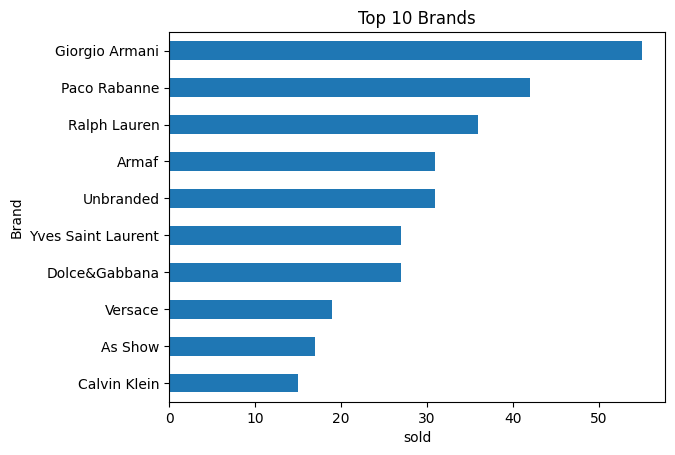

In [168]:
# Top 10 brands sold
top_brands = df1['brand'].value_counts().head(10)

top_brands.sort_values().plot(kind='barh')

plt.xlabel('sold')
plt.ylabel('Brand')
plt.title('Top 10 Brands')
plt.show()

The analysis shows that Brand Giorgio has the highest number of listings among the top 10 brands,and carolina Herrerra indicating that it has the strongest representation in the dataset.

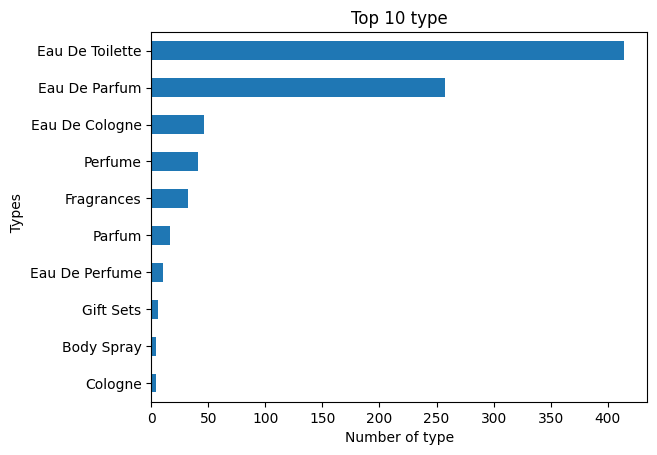

In [169]:
# Top 10 types
top_types = df1['type'].value_counts().head(10)

top_types.sort_values().plot(kind='barh')

plt.xlabel('Number of type')
plt.ylabel('  Types')
plt.title('Top 10 type')
plt.show()

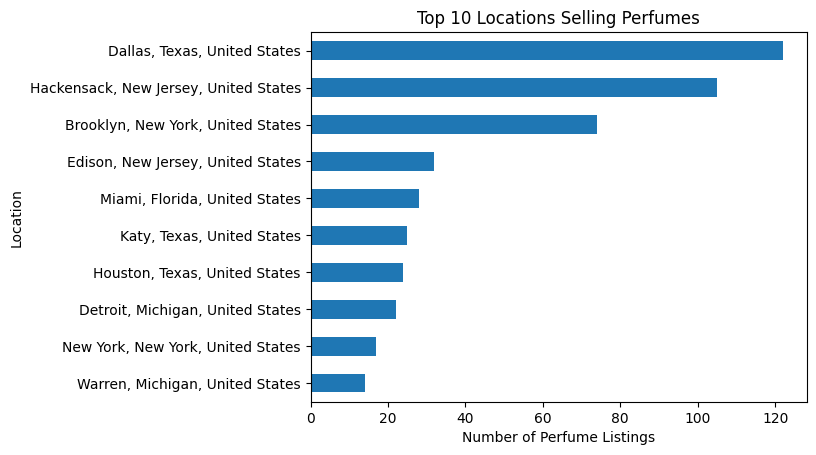

In [170]:
# Top 10 location
top_locations = df1['itemLocation'].value_counts().head(10)
top_locations.sort_values().plot(kind='barh')
plt.xlabel('Number of Perfume Listings')
plt.ylabel('Location')
plt.title('Top 10 Locations Selling Perfumes')
plt.show()

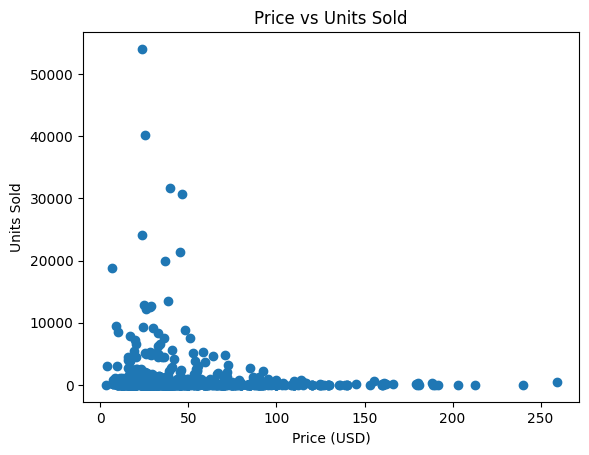

In [171]:
# Relationship between price and units sold
plt.scatter(df1['price'], df1['sold'])
plt.title('Price vs Units Sold')
plt.xlabel('Price (USD)')
plt.ylabel('Units Sold')
plt.show()

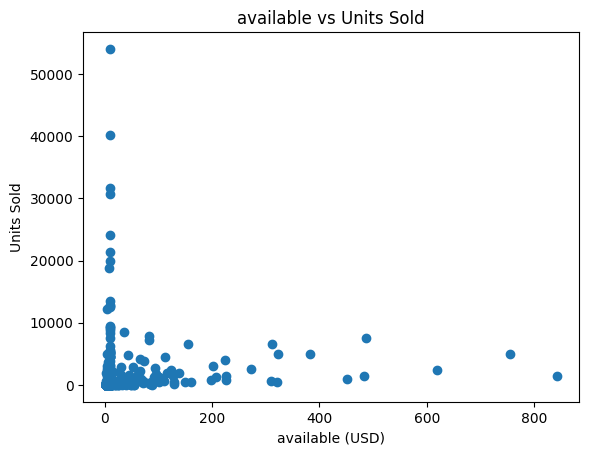

In [172]:
# Relationship between price and units sold
plt.scatter(df1['available'], df1['sold'])
plt.title('available vs Units Sold')
plt.xlabel('available (USD)')
plt.ylabel('Units Sold')
plt.show()

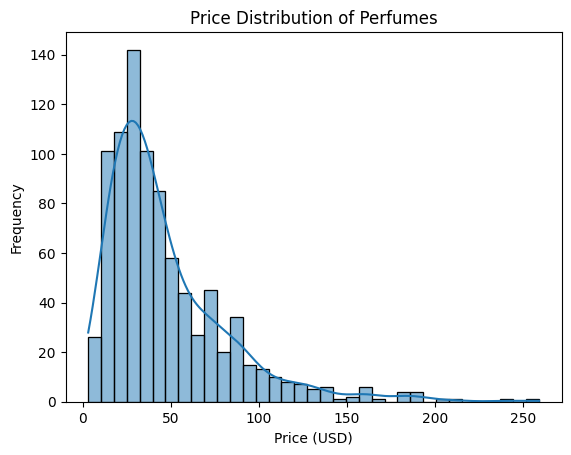

In [173]:
sns.histplot(df1['price'], kde=True)
plt.title('Price Distribution of Perfumes')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

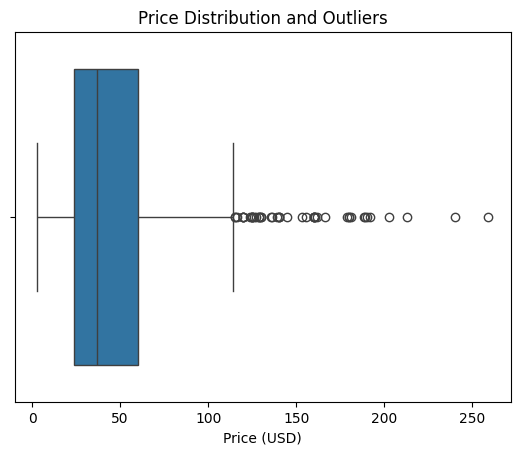

In [174]:
sns.boxplot(x=df1['price'])
plt.title('Price Distribution and Outliers')
plt.xlabel('Price (USD)')
plt.show()

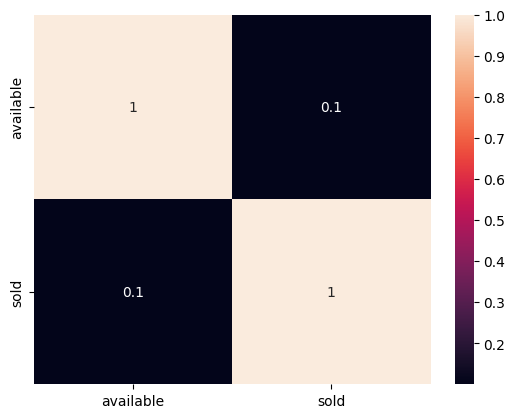

In [175]:
# Heatmap is used to used to visualize complex data instantly through colors to identify patterns,clusters and outliers ata single glance
corr = df1.select_dtypes(include='int64').corr()

sns.heatmap(corr, annot=True)
plt.show()

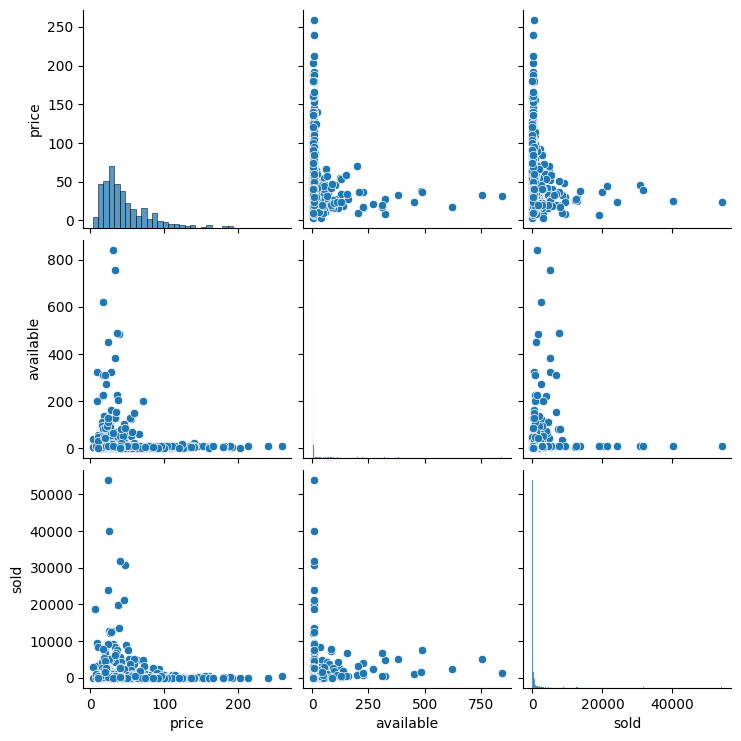

In [176]:
# Pair plot visualize individual columns as well as pairwise relationshipbetween multiple columns(scatter plot)
sns.pairplot(df1[['price', 'available', 'sold']])
plt.show()

# WOMEN PERFUME ANALYSIS

# Read the dataset into google colab

In [177]:
df2=pd.read_csv(r'ebay_womens_perfume.csv')

# Inspecting the data  using pandas functions

In [178]:
df2.shape

(1000, 10)

In [179]:
df2

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.0,2 available / 393 sold,393.0,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States"
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong"
2,PRADA,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.0,More than 10 available / 35 sold,35.0,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States"
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.0,More than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong"
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.0,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States"
...,...,...,...,...,...,...,...,...,...,...
995,Avon,Avon Far Away Infinity Eau de Parfum 1.7 fl. o...,Eau de Parfum,13.89,US $13.89,10.0,More than 10 available / 157 sold,157.0,"May 16, 2024 22:35:29 PDT","West Palm Beach, Florida, United States"
996,Mancera,Roses Greedy by Mancera perfume for unisex EDP...,Eau de Parfum,57.85,US $57.85/ea,33.0,33 available / 58 sold,58.0,"May 24, 2024 08:03:11 PDT","Dallas, Texas, United States"
997,Unbranded,"Sweet Tooth Eau de Parfum, Perfume for Women, ...",1,30.96,US $30.96,2.0,2 available / 3 sold,3.0,"May 17, 2024 23:16:41 PDT","New York, New York, United States"
998,Juliette Has A Gun,MMMM BY Juliette Has A Gun perfume for her EDP...,Eau de Perfume,53.99,US $53.99/ea,3.0,3 available / 117 sold,117.0,"May 13, 2024 22:19:34 PDT","Dallas, Texas, United States"


In [180]:
df2.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.0,2 available / 393 sold,393.0,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States"
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong"
2,PRADA,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.0,More than 10 available / 35 sold,35.0,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States"
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.0,More than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong"
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.0,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States"


In [181]:
df2.tail()


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
995,Avon,Avon Far Away Infinity Eau de Parfum 1.7 fl. o...,Eau de Parfum,13.89,US $13.89,10.0,More than 10 available / 157 sold,157.0,"May 16, 2024 22:35:29 PDT","West Palm Beach, Florida, United States"
996,Mancera,Roses Greedy by Mancera perfume for unisex EDP...,Eau de Parfum,57.85,US $57.85/ea,33.0,33 available / 58 sold,58.0,"May 24, 2024 08:03:11 PDT","Dallas, Texas, United States"
997,Unbranded,"Sweet Tooth Eau de Parfum, Perfume for Women, ...",1,30.96,US $30.96,2.0,2 available / 3 sold,3.0,"May 17, 2024 23:16:41 PDT","New York, New York, United States"
998,Juliette Has A Gun,MMMM BY Juliette Has A Gun perfume for her EDP...,Eau de Perfume,53.99,US $53.99/ea,3.0,3 available / 117 sold,117.0,"May 13, 2024 22:19:34 PDT","Dallas, Texas, United States"
999,Paris Hilton,PARIS HILTON ELECTRIFY for Women Cologne 3.4 o...,Eau de Parfum,14.99,US $14.99/ea,4.0,4 available / 51 sold,51.0,"May 22, 2024 05:44:45 PDT","TX, United States"


In [182]:
df2.columns

Index(['brand', 'title', 'type', 'price', 'priceWithCurrency', 'available',
       'availableText', 'sold', 'lastUpdated', 'itemLocation'],
      dtype='object')

In [183]:
df2.dtypes

,0
brand,object
title,object
type,object
price,float64
priceWithCurrency,object
available,float64
availableText,object
sold,float64
lastUpdated,object
itemLocation,object


In [184]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               998 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          869 non-null    float64
 6   availableText      992 non-null    object 
 7   sold               984 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [185]:
df2.describe()

,price,available,sold
count,1000.000000,869.000000,984.000000
mean,39.892980,21.426928,497.321138
std,29.072186,51.476703,1372.510561
min,1.990000,2.000000,1.000000
25%,20.700000,6.000000,15.000000
50%,32.990000,10.000000,52.000000
75%,49.990000,10.000000,263.750000
max,299.990000,557.000000,17854.000000


In [186]:
df2.describe(include='object')

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: FutureWarning: Parsed string "May 08, 2024 16:32:50 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,brand,title,type,priceWithCurrency,availableText,lastUpdated,itemLocation
count,999,1000,998,1000,992,927,1000
unique,247,975,71,655,746,911,299
top,Lancôme,Idole by Lancome Eau de Parfum EDP Perfume for...,Eau de Parfum,US $49.99/ea,More than 10 available / 3 sold,"May 08, 2024 16:32:50 PDT","Dallas, Texas, United States"
freq,37,4,562,20,7,5,141


In [187]:
df2.drop(columns=['priceWithCurrency','availableText'],inplace=True)

In [188]:
df2.rename(columns={'lastUpdated': 'date'}, inplace=True)

In [189]:
df2.drop(columns=['date'],inplace=True)

In [190]:
df2.columns

Index(['brand', 'title', 'type', 'price', 'available', 'sold', 'itemLocation'], dtype='object')

#Checking for missing values and dulplicate values

In [191]:
df2.duplicated().sum()

np.int64(1)

In [192]:
df2.isnull().sum()

,0
brand,1
title,0
type,2
price,0
available,131
sold,16
itemLocation,0


# Both duplicates and null values are present they should be treated

In [193]:
# Removing duplicate values
df2.drop_duplicates(inplace=True)

In [194]:
# Removed successfully
df2.duplicated().sum()

np.int64(0)

In [195]:
# Treating 1 missing value in brand column using mode method
df2['brand']=df2['brand'].fillna(df2['brand'].mode()[0])


In [196]:
# Treating 2 missing values in type column using mode method
df2['type']=df2['type'].fillna(df2['type'].mode()[0])


In [197]:
df2.isnull().sum()

,0
brand,0
title,0
type,0
price,0
available,131
sold,16
itemLocation,0


In [198]:
# The distribution is skewed
df2['available'].skew()

np.float64(5.56843239646848)

In [199]:
# Since the distribution is skewed using median method to fill
df2['available']=df2['available'].fillna(df2['available'].median())

In [200]:
df2['available'] = pd.to_numeric(df2['available']).astype(int)

In [201]:
# The distribution of this column is skewed
df2['sold'].skew()


np.float64(5.927347656057624)

In [202]:
# Since the distribution is skewed using median method to fill missing values
df2['sold']=df2['sold'].fillna(df2['sold'].median())

# Treated all missing values

In [203]:
df2.isnull().sum()



,0
brand,0
title,0
type,0
price,0
available,0
sold,0
itemLocation,0


# Standardizing the datatypes


In [204]:
df2.dtypes

,0
brand,object
title,object
type,object
price,float64
available,int64
sold,float64
itemLocation,object


In [205]:
# Sold column cannot be in float so converting it into int
df2['sold']=pd.to_numeric(df2['sold']).astype(int)

# Identifying the outliers using boxplot

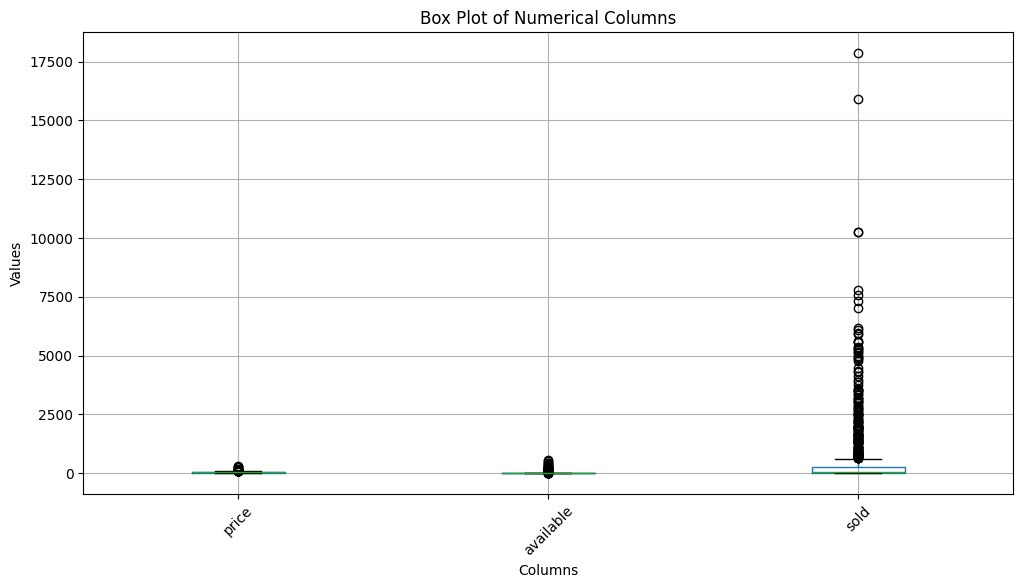

In [206]:
numerical_cols = df2.select_dtypes(include='number')

plt.figure(figsize=(12, 6))
numerical_cols.boxplot()

plt.title('Box Plot of Numerical Columns')
plt.xlabel('Columns')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()

# Yes all 3 colimns contain outliers

# Detecting the distribution
# If the distribution is skewed go with IQR Method ,or 3 sigma method for normal distribution

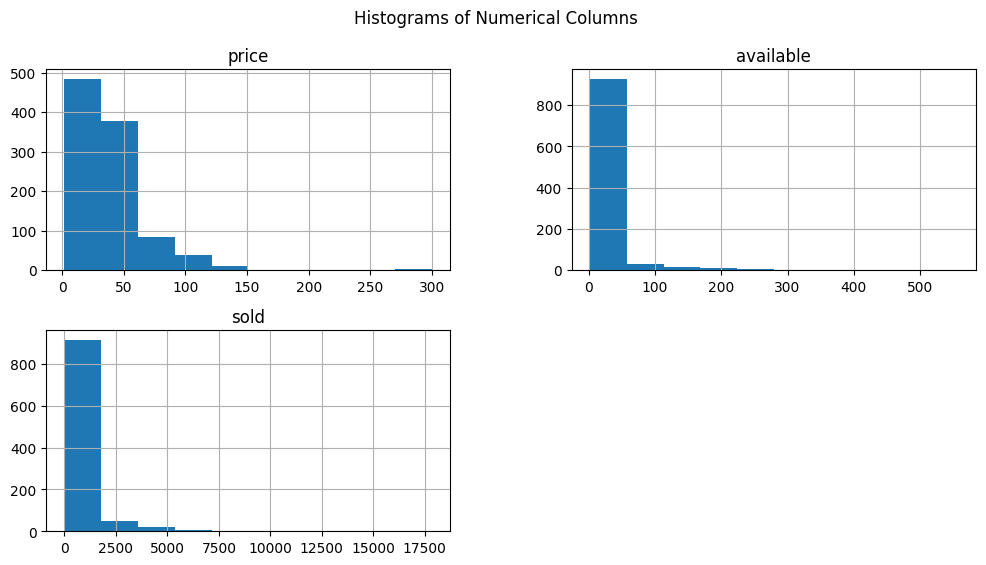

In [207]:
numerical_cols = df2.select_dtypes(include='number')

numerical_cols.hist(figsize=(12, 6))

plt.suptitle('Histograms of Numerical Columns')
plt.show()

In [208]:
# Now lets see how many outliers are present in each column
Q1 = df2[['available', 'price', 'sold']].quantile(0.25)
Q3 = df2[['available', 'price', 'sold']].quantile(0.75)

IQR = Q3 - Q1


outliers = ((df2[['available', 'price', 'sold']] < (Q1 - 1.5 * IQR)) |
            (df2[['available', 'price', 'sold']] > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
available,118
price,52
sold,148


# Identifying the IQR Boundaries

In [209]:

for col in ['available', 'price', 'sold']:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col)
    print("Lower:", lower)
    print("Upper:", upper)

available
Lower: 0.0
Upper: 16.0
price
Lower: -23.26
Upper: 93.94
sold
Lower: -348.0
Upper: 620.0


# Inspecting the actual values , to decide whether to remove , keep or cap

In [210]:
# These values are not outliers , they just represent costly perfumes
df2[df2['price'] > 93.94]['price'].sort_values()


,price
865,94.99
880,95.00
196,95.99
55,98.99
484,99.00
872,99.00
487,99.00
598,99.95
597,99.99
583,99.99


In [211]:

df2[df2['available'] > 16]['available'].sort_values()


,available
339,17
441,18
545,19
989,19
624,20
...,...
298,408
439,413
154,417
698,500


In [212]:
# A perfume selling 17,854 units could genuinely be a highly popular product.
df2[df2['sold'] > 620]['sold'].sort_values()

,sold
326,626
587,635
424,651
206,655
905,662
...,...
386,7773
172,10259
108,10268
359,15897


 # Conclusion
# The numerical variables available, price, and sold exhibit right-skewed distributions, indicating that most products are concentrated at lower values while a smaller number of products have substantially higher values. The IQR method identified potential outliers in all three variables. However, these extreme observations may represent genuine business conditions, such as higher inventory, premium-priced perfumes, or highly popular products. Therefore, the outliers should not be removed solely based on statistical detection and were retained after considering their business relevance.

# Exploratory Data Analysis

# Univariate analysis using box plot , histogram and count plot


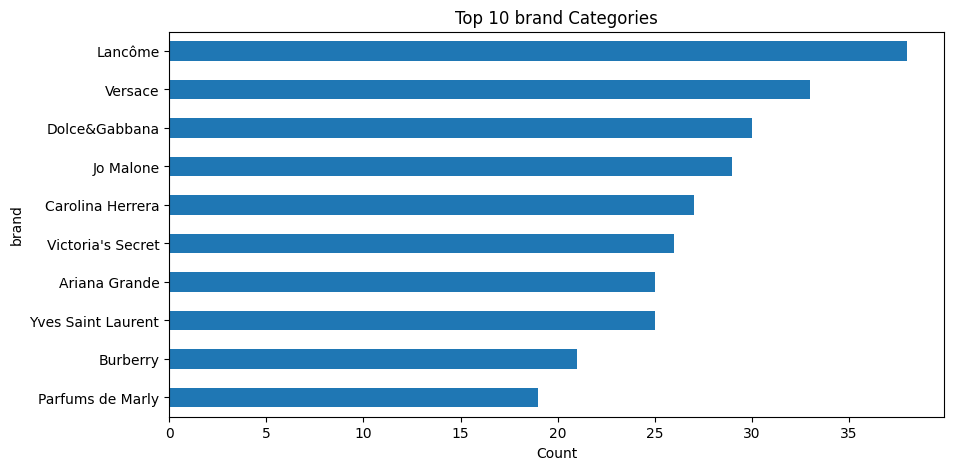

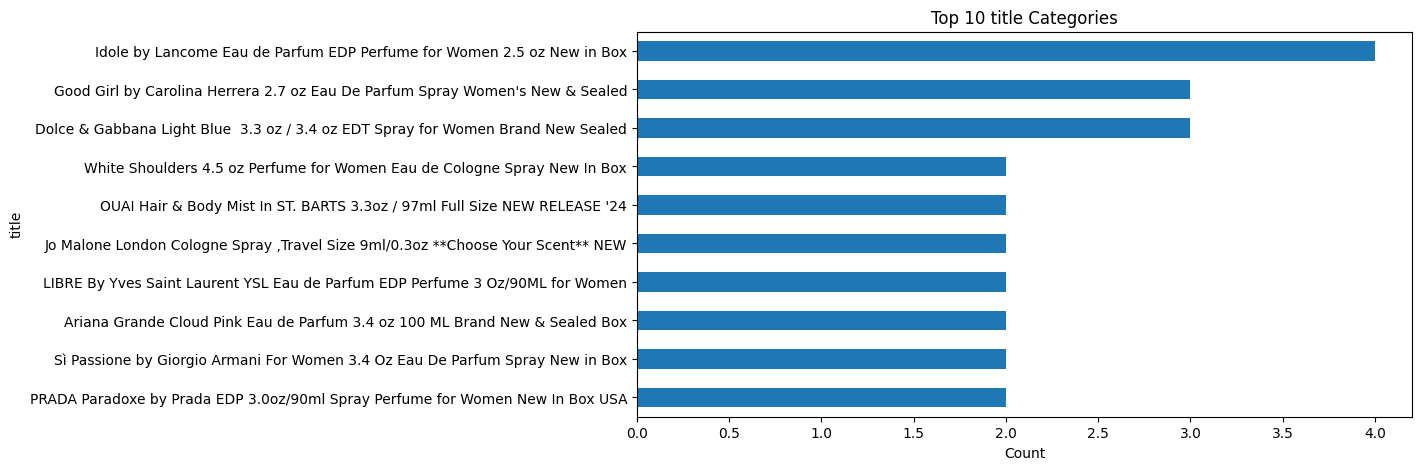

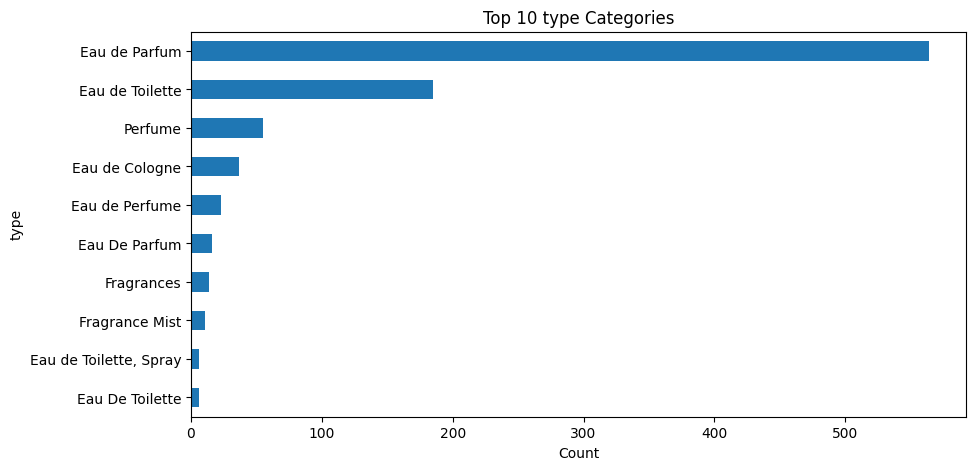

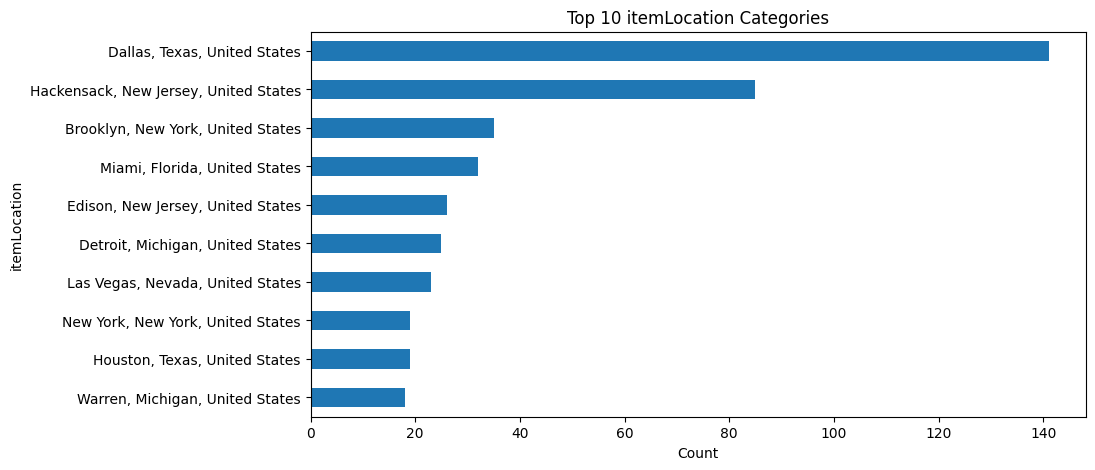

In [213]:
categorical_cols = df2.select_dtypes(include='object').columns

for col in categorical_cols:
    top_10 = df2[col].value_counts().head(10).sort_values()

    plt.figure(figsize=(10, 5))
    top_10.plot(kind='barh')

    plt.title(f'Top 10 {col} Categories')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

# Bivariate Analysis

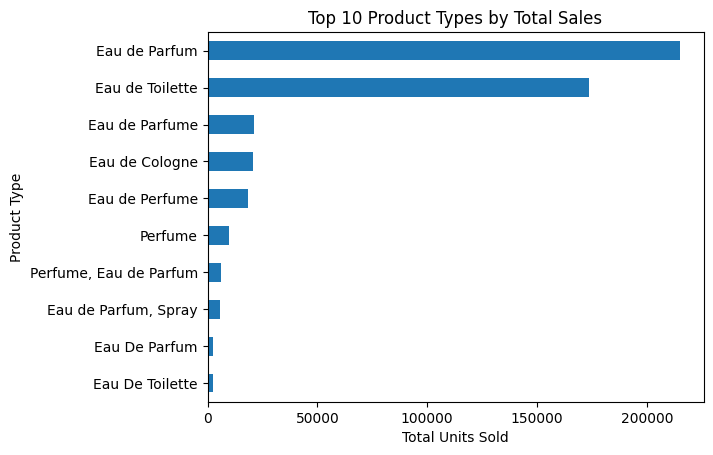

In [214]:
top_10_types = df2.groupby('type')['sold'].sum().nlargest(10)
top_10_types.sort_values().plot(kind='barh')

plt.title('Top 10 Product Types by Total Sales')
plt.xlabel('Total Units Sold')
plt.ylabel('Product Type')
plt.show()

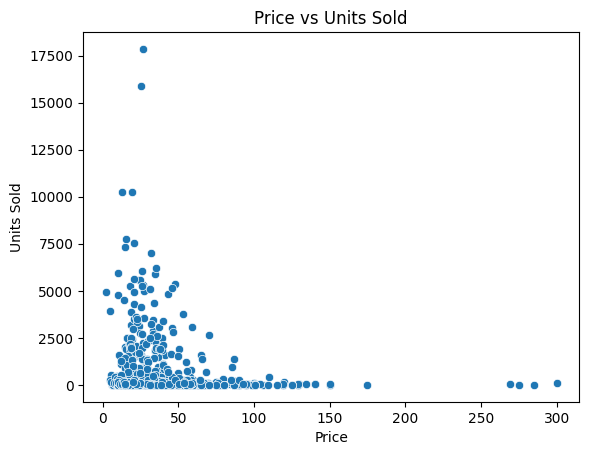

In [215]:
sns.scatterplot(data=df2, x='price', y='sold')

plt.title('Price vs Units Sold')
plt.xlabel('Price')
plt.ylabel('Units Sold')
plt.show()

# Multivariate Analysis

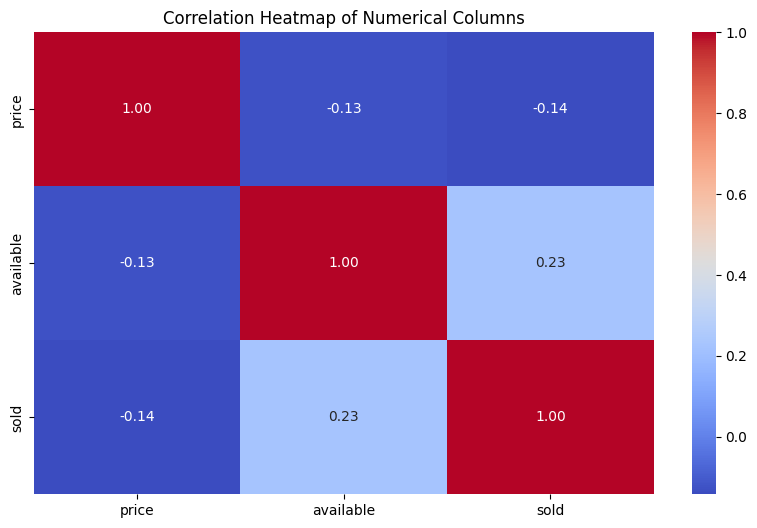

In [216]:
# Select numerical columns
numerical_cols = df2.select_dtypes(include='number')

# Calculate correlation
correlation = numerical_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

###Insight

* **Price vs Sold:** Weak negative correlation (**-0.14**) → higher prices are slightly associated with lower sales.
* **Available vs Sold:** Moderate positive correlation (**0.30**) → products with greater availability tend to have somewhat higher sales.
* **Price vs Available:** Weak negative correlation (**-0.14**) → higher-priced products tend to have slightly lower availability.
* **Overall:** The correlations are relatively weak, so **price and availability alone do not strongly explain sales**. Other factors likely influence product sales.


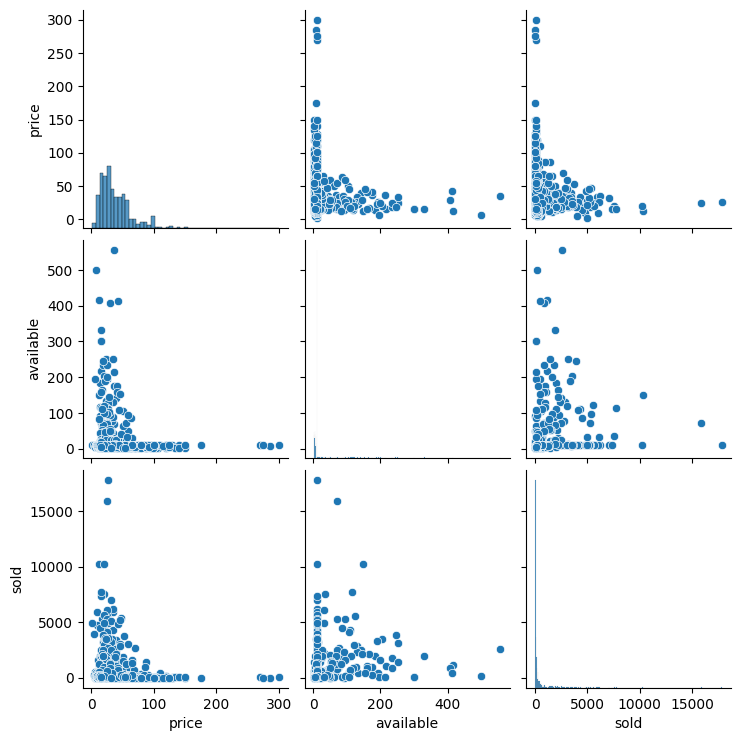

In [217]:
numerical_cols = df2.select_dtypes(include='number')

sns.pairplot(numerical_cols)

plt.show()

**Insight**

The data is highly skewed, with most products concentrated at low price, availability, and sales levels. Lower-priced products generally show higher sales, suggesting that price may influence demand. However, the relationships involving availability are relatively weak, and several extreme outliers are present. Therefore, further analysis should consider outlier treatment and possibly log transformation before building predictive models.

**Downloading the cleeaned datasets**

In [218]:
df1.to_csv('cleaned_men_perfume.csv', index=False)

In [219]:
from google.colab import files
files.download('cleaned_men_perfume.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [220]:
df2.to_csv('cleaned_women_perfume.csv', index=False)

In [221]:
from google.colab import files
files.download('cleaned_women_perfume.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>